In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sympy as sp
import ipywidgets as ip
from ipywidgets import interact
from ipywidgets import widgets
from numpy import *
from matplotlib.pyplot import *
from matplotlib.patches import Rectangle
from IPython.display import display
import matplotlib
matplotlib.rcParams['animation.embed_limit'] = 2**128

# Configurar el backend adecuado para Voilà
plt.ioff()  # Desactivar modo interactivo

In [2]:
encabezado = """
<div style="background-color: gainsboro; padding: 15px;font-family: Times New Roman; font-size:1.2em;text-align:right; color:black;">
    Área de fisicoquímica<br>Escuela de Ingeniería Química<br>Facultad de Ingeniería<br>Universidad de San Carlos de Guatemala
</div>
"""

html_encabezado = widgets.HTML(value=encabezado)

In [3]:
titulo = """
<div style="background-color: powderblue; padding: 20px;font-family: Times New Roman; font-size:2em;text-align:center; color:black;">
    Primera ley de la termodinámica
</div>
<div style="background-color: lemonchiffon; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    La primera ley de la termodinámica no es nueva para nosotros, ya la hemos estudiado en otros cursos, por ejemplo en Física. La primera ley de la termodinámica nos dice que un sistema intercambia energía con sus alrededores, es decir puede recibir energía de los alrededores o transferir energía a los alrededores. El cambio de energía del sistema puede ser expresada con una ecuación, que representa su balance de energía:
</div>
<div style="background-color: lemonchiffon; padding: 20px;font-family: Times New Roman; font-size:1.3em; text-align:center; color:black;">
    ΔE=ΔE<sub>k</sub>+ΔE<sub>P</sub>+ΔU
</div>
<div style="background-color: lemonchiffon; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Esta ecuación nos permite ver que el cambio en la energía del sistema se puede atribuir a cambios en la energía cinética (E<sub>k</sub>), potencial (E<sub>P</sub>) y en la energía interna del sistema (U).
</div>
<div style="background-color: lemonchiffon; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Recordemos algunos ejemplos en donde hemos evaluado la primera ley de la termodinámica. Por ejemplo, en la siguiente animación al hacer clic en play puedes hacer que el carro se mueva. ¿Qué necesita este sistema para moverse?
</div>
"""

html_titulo = widgets.HTML(value=titulo)

In [4]:

def carro(x):
    plt.rcParams['figure.figsize']=(6,6)
    plt.xlim(xmin=0, xmax=13)
    plt.ylim(ymin=0, ymax=10)
    rect = Rectangle((0.5+x,1),1.5,1,color='lightcoral',ec='black')
    circ=Circle((0.7+x,1),0.15,color='darkgrey',ec='black')
    circ2=Circle((1.8+x,1),0.15,color='darkgrey',ec='black')
    plt.gca().add_patch(rect);
    plt.gca().add_patch(circ);
    plt.gca().add_patch(circ2); 
    plt.gca().annotate('44',xy=(0.9+x,1.5));
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    car = plt.show()

x=0


In [5]:
out_carro = widgets.Output(layout=widgets.Layout(
        height='480px',
        max_height='480px',
        min_height='480px',
        overflow_x='hidden',
        overflow_y='hidden', 
        flex_grow=0, 
        flex_shrink=0))

In [6]:
control = widgets.Play(
    value=x,
    step=1,
    min=0,
    max=13.5,
    interval=100,
    description="Press play",
    disabled=False
)

def actualizar(change):
    with out_carro:
        out_carro.clear_output(wait=True)
        carro(change["new"])

control.observe(actualizar, names="value")

ui = widgets.VBox([
    html_encabezado,
    html_titulo,
    control,
    out_carro]
   )

with out_carro:
    carro(x)

display(ui)

In [7]:
movingcar = """
<div style="background-color: lemonchiffon; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    En el caso del carro ¿qué tipo de energía debe tomarse en cuenta en el balance? ¿Energía cinética E<sub>k</sub>? ¿Energía potencial E<sub>k</sub>? ¿Energía interna (U)?
</div>
<div style="background-color: lemonchiffon; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black; text-align:center;">
 ΔE=ΔE<sub>k</sub>+ΔE<sub>P</sub>+ΔU
</div>
"""
html_movingcar=widgets.HTML(value=movingcar)

In [8]:
texto_carro = widgets.Output()
def actualizar_carro(respuesta):
    texto_carro.clear_output()
    with texto_carro:
        if respuesta=='Energía cinética':
            print('Correcto, el sistema experimenta un cambio en su energía cinética, pues intercambia energía con su entorno, en este caso la quema del combustible ')
        if respuesta== 'Energía potencial':
            print('Incorrecto, el carro no cambia su posición dentro de un campo de fuerza (por ejemplo el campo gravitacional)')
        if respuesta== 'Energía interna':
            print('Incorrecto, aunque la energía cinética del carro si cambia, la energía interna de las partículas del carro no se altera ')
        if respuesta== 'Energía cinética y potencial':
            print('Incorrecto, la energía cinética si cambia, pero la potencial no')
        else:
            print(' ')

respuesta = ['Energía cinética', 'Energía potencial', 'Energía interna','Energía cinética y potencial']

boton  = widgets.RadioButtons(
    options=respuesta,
    value=None,         
    disabled=False
)

def boton_change(change):
    actualizar_carro(change['new'])

boton.observe(boton_change, names='value')

display(
    widgets.VBox([
        html_movingcar,
        boton,
        texto_carro
    ])
)

In [9]:
pelota = """
<div style="background-color: lemonchiffon; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    Ahora veamos el caso de una pelota que va cayendo, puedes hacer que se mueva haciendo clic en play.
</div>
"""
html_pelota= widgets.HTML(value=pelota)

In [10]:
def ball(x): 
    plt.rcParams['figure.figsize']=(6,6)
    plt.xlim(xmin=0, xmax=10)
    plt.ylim(ymin=0, ymax=10)
    circulo=Circle((5,9.5-x),0.5,color='coral',ec='black')
    plt.gca().add_patch(circulo);
    plt.gca().annotate('W',xy=(4.83,9.4-x));
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    ball = plt.show()
    display(ball)
    
x=0

out_ball = widgets.Output(layout=widgets.Layout(height='480px', overflow='hidden'))

pelotacontrol = widgets.Play(
    value=x,
    step=1,
    min=0,
    max=9.5,
    interval=100,
    description="Press play",
    disabled=False
)

def actualizar(change):
    with out_ball:
        out_ball.clear_output(wait=True)
        ball(change["new"])

pelotacontrol.observe(actualizar, names="value")

redondo = widgets.VBox([
    html_pelota,
    pelotacontrol,
    out_ball
])

with out_ball:
    ball(x)

display(redondo)

In [11]:
pelota2 = """
<div style="background-color: lemonchiffon; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    En el caso de la pelota ¿qué tipo de energía debe tomarse en cuenta en su balance de energía? ¿Energía cinética (E<sub>k</sub>)? ¿Energía potencial (ΔE<sub>p</sub>)? ¿Energía interna (U)? 
</div>
<div style="background-color: lemonchiffon; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black; text-align:center;">
 ΔE=ΔE<sub>k</sub>+ΔE<sub>P</sub>+ΔU
</div>
"""
html_pelota2= widgets.HTML(value=pelota2)

In [12]:
out_texto = widgets.Output()
def actualizar_texto(formas):
    out_texto.clear_output()
    with out_texto:
        if formas=='Energía cinética y potencial':
            print('Correcto, el sistema experimenta un cambio en su energía cinética, y un cambio en su energía potencial ΔE=ΔEk+ΔEp ')
        if formas== 'Energía potencial':
            print('Incorrecto, la energía cinética de la pelota también cambia')
        if formas== 'Energía interna':
            print('Incorrecto, la energía interna de la pelota no cambia, es decir no hay cambio en la energía de las partículas que forman la pelota')
        if formas== 'Energía cinética':
            print('Incorrecto, la energía potencial de la pelota también cambia ')
        else:
            print(' ')

opciones = ['Energía cinética y potencial', 'Energía potencial', 'Energía interna','Energía cinética']

radio = widgets.RadioButtons(
    options=opciones,
    value=None,         
    disabled=False
)

def on_radio_change(change):
    actualizar_texto(change['new'])

radio.observe(on_radio_change, names='value')

display(
    widgets.VBox([
        html_pelota2,
        radio,
        out_texto   
    ])
)

In [13]:
comparar = """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    Compara los escenarios anteriores con el siguiente ejemplo en el que el agua (en fase líquida) dentro de un beaker se pone en contacto con una estufa eléctrica. ¿Qué sucede con el agua cuando se enciende la estufa?
</div>
"""
html_comparar= widgets.HTML(value=comparar)

In [14]:
def estufacil (ON=False):
    plt.rcParams['figure.figsize']=(6,6)
    plt.figure()  
    if ON:
        x= np.array([5,6,7,8])
        y= np.array([10,10,10,10])
        plt.plot(x,y,color='black')
        e= np.array([5,6,7,8])
        i= np.array([50,50,50,50])
        plt.plot(e,i,color='black')
        plt.fill_between(x,i,y, alpha=0.25)
        a= np.array([5,5,5])
        b= np.array([10,18,60])
        plt.plot(a, b, color='black')
        z= np.array([8,8,8])
        w= np.array([10,18,60])
        plt.plot(z, w, color='black')
        plt.xlim(xmin=0, xmax=13)
        plt.ylim(ymin=0, ymax=100)
        plt.ylabel("Volumen (L)")
        plt.gca().set_xticks([])
        plt.gca().set_yticks([])
        plt.title("Estado 2")
        rect = Rectangle((4,0),5,10,color='lightcoral',ec='black')
        plt.gca().add_patch(rect)
        plt.gca().annotate('Estufa ON',xy=(5.5,2));
        graf4 = plt.show()
        display(graf4)
        
    else:
        x= np.array([5,6,7,8])
        y= np.array([10,10,10,10])
        plt.plot(x,y,color='black')
        e= np.array([5,6,7,8])
        i= np.array([30,30,30,30])
        plt.plot(e,i,color='black')
        plt.fill_between(x,i,y, alpha=0.25)
        a= np.array([5,5,5])
        b= np.array([10,18,60])
        plt.plot(a, b, color='black')
        z= np.array([8,8,8])
        w= np.array([10,18,60])
        plt.plot(z, w, color='black')
        plt.xlim(xmin=0, xmax=13)
        plt.ylim(ymin=0, ymax=100)
        plt.ylabel("Volumen (L)")
        plt.gca().set_xticks([])
        plt.gca().set_yticks([])
        plt.title("Estado 1")
        rect = Rectangle((4,0),5,10,color='lightgrey',ec='black')
        plt.gca().add_patch(rect)
        plt.gca().annotate('Estufa OFF',xy=(5.5,2));
        graf3 = plt.show()
        display(graf3)
        plt.show()

In [15]:
out_estufa = widgets.Output(layout=widgets.Layout(height='580px', overflow='hidden'))

with out_estufa:
    estufacil(False)

control = widgets.ToggleButton(
    value=False,
    description="Estufa ON / OFF"
)

def encender(change):
    with out_estufa:
        out_estufa.clear_output(wait=True)
        estufacil(change["new"])

control.observe(encender, names="value")

display(
    widgets.VBox([
    html_comparar,
    control,
    out_estufa
    ])
)

In [16]:
explicar = """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    El sistema, en este caso el beaker no se desplaza a ningún lugar como el automóvil, por lo que no hay cambio en su energía cinética.
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
ΔE=<del>ΔE<sub>k</sub></del>+ΔE<sub>p</sub>+ΔU<br>
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    El beaker no cambia de posición respecto a un campo de fuerza, esto implica que no hay cambio en su energía potencial.
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
ΔE=<del>ΔE<sub>k</sub></del>+<del>ΔE<sub>p</sub></del>+ΔU
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Es decir que sólo hay cambio en la energía interna del sistema.
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
ΔE=ΔU
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
¿Qué quiere decir esto?
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Al encender la estufa, esta transfiere energía forma de calor al agua. Esta energía hace que las moléculas del agua se muevan más rápidamente, es decir a nivel microscópico la energía cinética de las moléculas de agua aumenta (observa en las animaciones la diferencia en la velocidad de movimiento de las partículas).
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
ΔE=ΔU
</div>
"""
html_explicar= widgets.HTML(value=explicar)
display(html_explicar)

HTML(value='\n<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1…

In [17]:
def estufaapagada():
    dibujo, ax1 = plt.subplots()
    m= np.array([4,6,7,10])
    n= np.array([2,2,2,2])
    ax1.plot(m,n,color='black')
    f= np.array([4,6,7,10])
    g= np.array([5,5,5,5])
    ax1.plot(f,g,color='black')
    ax1.fill_between(m,g,n, alpha=0.25)
    l= np.array([4,4,4])
    v= np.array([2,5,12])
    ax1.plot(l, v, color='black')
    u= np.array([10,10,10])
    r= np.array([2,5,12])
    ax1.plot(u, r, color='black')
    ax1.set_ylabel("Volumen (L)")
    rect = Rectangle((2,0),10,2,color='lightgrey',ec='black')
    ax1.add_patch(rect)
    ax1.annotate('Estufa OFF',xy=(5,0.5))
    ax1.set_aspect(1)
    ax1.set_xlim(0, 14)
    ax1.set_ylim(0, 14)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_title("Estado 1")
    plt.show()

In [18]:
# Generar posiciones de partículas una sola vez para mantener coherencia
num_particles = 25
particle_positions = {
    i: (np.clip(np.random.rand(num_particles),0,1), np.clip(np.random.rand(num_particles),0,1)) 
    for i in range(10)
}

par_num = 25
posicion_particula = {
    i: (np.clip(np.random.rand(par_num),0,1), np.clip(np.random.rand(par_num),0,1))
    for i in range(10)
}

nueva_par= 25
lieu_particula = {
    i: (np.clip(np.random.rand(nueva_par),0,1), np.clip(np.random.rand(nueva_par),0,1))
    for i in range(10)
}

new_par= 25
place_particula = {
    i: (np.clip(np.random.rand(new_par),0,1), np.clip(np.random.rand(new_par),0,1))
    for i in range(10)
}

# Función para actualizar la visualización
def update_plot(t):
    # Limpiar la figura anterior
    plt.close('all')
    
    # Crear nueva figura
    fig, (ax2) = plt.subplots()
    
    # Dibujar el segundo panel (moleculas)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_title("Moléculas de agua")
    ax2.set_aspect(1)
    
    # Usar las posiciones de partículas pre-generadas
    a, b = particle_positions[t]
    c, d = posicion_particula[t]
    e, j = lieu_particula[t]
    k, h = place_particula[t]
    # Añadir un poco de movimiento a las partículas basado en t
    a_adjusted = np.clip(a+t*0.01,0,1)
    b_adjusted = np.clip(b+t*0.01,0,1)
    c_adjusted = np.clip(c-t*0.01,0,1)
    d_adjusted = np.clip(d-t*0.01,0,1)
    e_adjusted = np.clip(e+t*0.05,0,1)
    j_adjusted = np.clip(j+t*0.05,0,1)
    k_adjusted = np.clip(k-np.sin(t*0.05),0,1)
    h_adjusted = np.clip(h-np.sin(t*0.05),0,1)
    
    ax2.scatter(a_adjusted, b_adjusted, color='lightskyblue')
    ax2.scatter(c_adjusted, d_adjusted, color='lightskyblue')
    ax2.scatter(e_adjusted, j_adjusted, color='lightskyblue')
    ax2.scatter(k_adjusted, h_adjusted, color='lightskyblue')
    
    plt.tight_layout()
    return fig

# Crear widgets
play_button = widgets.Play(
    value=0,
    min=0,
    max=9,
    step=1,
    interval=1000,  # milisegundos entre frames
    description="Play",
    disabled=False
)

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=9,
    step=1,
    description="Frame:",
    disabled=False
)

# Vincular widgets
widgets.jslink((play_button, 'value'), (slider, 'value'))

# Widget de salida para la figura
output_widget = widgets.Output()
estufa_apagada = widgets.Output()

with estufa_apagada:
    estufaapagada()

def on_value_change(change):
    with output_widget:
        output_widget.clear_output(wait=True)
        fig = update_plot(change['new'])
        display(fig)

# Conectar el slider a la función de actualización
slider.observe(on_value_change, names='value')




# Crear el layout final
controls = widgets.VBox([play_button])
ui = widgets.VBox([estufa_apagada, controls, output_widget])

# Mostrar la interfaz
display(ui)




In [19]:
def estufaencendida():
    estufa, ax1 = plt.subplots()
    x= np.array([4,6,7,10])
    y= np.array([2,2,2,2])
    ax1.plot(x,y,color='black')
    e= np.array([4,6,7,10])
    i= np.array([10,10,10,10])
    ax1.plot(e,i,color='black')
    ax1.fill_between(x,i,y, alpha=0.25)
    a= np.array([4,4,4])
    b= np.array([2,5,12])
    ax1.plot(a, b, color='black')
    z= np.array([10,10,10])
    w= np.array([2,5,12])
    ax1.plot(z, w, color='black')
    ax1.set_ylabel("Volumen (L)")
    rect = Rectangle((2,0),10,2,color='lightcoral',ec='black')
    ax1.add_patch(rect)
    ax1.annotate('Estufa ON',xy=(5,0.5))
    ax1.set_aspect(1)
    ax1.set_xlim(0, 14)
    ax1.set_ylim(0, 14)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_title("Estado 2")
    plt.show()

In [20]:
# Generar posiciones de partículas una sola vez para mantener coherencia
num_particles = 25
particle_positions = {
    i: (np.clip(np.random.rand(num_particles),0,1), np.clip(np.random.rand(num_particles),0,1)) 
    for i in range(10)
}

par_num = 25
posicion_particula = {
    i: (np.clip(np.random.rand(par_num),0,1), np.clip(np.random.rand(par_num),0,1))
    for i in range(10)
}

nueva_par= 25
lieu_particula = {
    i: (np.clip(np.random.rand(nueva_par),0,1), np.clip(np.random.rand(nueva_par),0,1))
    for i in range(10)
}

new_par= 25
place_particula = {
    i: (np.clip(np.random.rand(new_par),0,1), np.clip(np.random.rand(new_par),0,1))
    for i in range(10)
}

# Función para actualizar la visualización
def update_plot(t):
    # Limpiar la figura anterior
    plt.close('all')
    
    # Crear nueva figura
    fig, (ax2) = plt.subplots()
    
    # Dibujar el segundo panel (moleculas)
    ax2.set_xlim(0, 1)
    ax2.set_ylim(0, 1)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_title("Moléculas de agua")
    ax2.set_aspect(1)
    
    # Usar las posiciones de partículas pre-generadas
    a, b = particle_positions[t]
    c, d = posicion_particula[t]
    e, j = lieu_particula[t]
    k, h = place_particula[t]
    # Añadir un poco de movimiento a las partículas basado en t
    a_adjusted = np.clip(a+t*0.01,0,1)
    b_adjusted = np.clip(b+t*0.01,0,1)
    c_adjusted = np.clip(c-t*0.01,0,1)
    d_adjusted = np.clip(d-t*0.01,0,1)
    e_adjusted = np.clip(e+t*0.05,0,1)
    j_adjusted = np.clip(j+t*0.05,0,1)
    k_adjusted = np.clip(k-np.sin(t*0.05),0,1)
    h_adjusted = np.clip(h-np.sin(t*0.05),0,1)
    
    ax2.scatter(a_adjusted, b_adjusted, color='lightskyblue')
    ax2.scatter(c_adjusted, d_adjusted, color='lightskyblue')
    ax2.scatter(e_adjusted, j_adjusted, color='lightskyblue')
    ax2.scatter(k_adjusted, h_adjusted, color='lightskyblue')
    
    plt.tight_layout()
    return fig

# Crear widgets
play_button = widgets.Play(
    value=0,
    min=0,
    max=9,
    step=1,
    interval=100,  # milisegundos entre frames
    description="Play",
    disabled=False
)

slider = widgets.IntSlider(
    value=0,
    min=0,
    max=9,
    step=1,
    description="Frame:",
    disabled=False
)

# Vincular widgets
widgets.jslink((play_button, 'value'), (slider, 'value'))

# Widget de salida para la figura
output_boton = widgets.Output()
estufa_encendida = widgets.Output()

with estufa_encendida:
    estufaencendida()

def on_value_change(change):
    with output_boton:
        output_boton.clear_output(wait=True)
        fig = update_plot(change['new'])
        display(fig)

# Conectar el slider a la función de actualización
slider.observe(on_value_change, names='value')




# Crear el layout final
controls = widgets.VBox([play_button])
gap = widgets.VBox([estufa_encendida, controls, output_boton])

# Mostrar la interfaz
display(gap)


In [21]:
explicar2= """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    La transferencia de energía en forma de calor está provocando un cambio en la energía interna del sistema.
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
U<sub>1</sub>< U<sub>2</sub>
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    El calor está provocando que la energía interna del segundo estado sea mayor que la energía interna del primer estado.
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
    Pero el calor no es la única forma en que la energía se está transfiriendo. Observemos que sucede con el volumen del agua en el beaker.
</div>
"""
html_explicar2= widgets.HTML(value=explicar2)

In [22]:
def comparacion():
    fig, (ax1, ax2) = plt.subplots(1,2)
    m= np.array([4,6,7,10])
    n= np.array([2,2,2,2])
    ax1.plot(m,n,color='black')
    f= np.array([4,6,7,10])
    g= np.array([5,5,5,5])
    ax1.plot(f,g,color='black')
    ax1.fill_between(m,g,n, alpha=0.25)
    l= np.array([4,4,4])
    k= np.array([2,5,12])
    ax1.plot(l, k, color='black')
    u= np.array([10,10,10])
    t= np.array([2,5,12])
    ax1.plot(u, t, color='black')
    ax1.set_ylabel("Volumen (L)")
    rect = Rectangle((2,0),10,2,color='lightgrey',ec='black')
    ax1.add_patch(rect)
    ax1.annotate('Estufa OFF',xy=(5,0.5))
    ax1.set_aspect(1)
    ax1.set_xlim(0, 14)
    ax1.set_ylim(0, 14)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_title("Estado 1")
    x= np.array([4,6,7,10])
    y= np.array([2,2,2,2])
    ax2.plot(x,y,color='black')
    e= np.array([4,6,7,10])
    i= np.array([10,10,10,10])
    ax2.plot(e,i,color='black')
    ax2.fill_between(x,i,y, alpha=0.25)
    a= np.array([4,4,4])
    b= np.array([2,5,12])
    ax2.plot(a, b, color='black')
    z= np.array([10,10,10])
    w= np.array([2,5,12])
    ax2.plot(z, w, color='black')
    ax2.set_ylabel("Volumen (L)")
    rect = Rectangle((2,0),10,2,color='lightcoral',ec='black')
    ax2.add_patch(rect)
    ax2.annotate('Estufa ON',xy=(5,0.5))
    ax2.set_aspect(1)
    ax2.set_xlim(0, 14)
    ax2.set_ylim(0, 14)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_title("Estado 2")
    plt.show()

In [23]:
explicar3= """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
A nivel microcópico podríamos observar que las moléculas de agua "empujan" a las moléculas de aire, logran hacer esto pues se está tranfiriendo energía, en este caso en forma de trabajo mecánico.
</div>
"""
html_explicar3= widgets.HTML(value=explicar3)

In [24]:
def work(y):
    k=[0.5,0.625,0.75,0.875,1,1.125,1.25,1.375,1.5,1.625,1.75,1.875,2,2.125,2.25,2.375,2.5,2.625,2.75,2.875,3,3.125,3.25,3.375,3.5]
    j=[1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y,1.8+y]
    a=[0.5,0.625,0.75,0.875,1,1.125,1.25,1.375,1.5,1.625,1.75,1.875,2,2.125,2.25,2.375,2.5,2.625,2.75,2.875,3,3.125,3.25,3.375,3.5]
    b=[2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y,2+y]
    e=[0.5,0.625,0.75,0.875,1,1.125,1.25,1.375,1.5,1.625,1.75,1.875,2,2.125,2.25,2.375,2.5,2.625,2.75,2.875,3,3.125,3.25,3.375,3.5]
    f=[1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y,1.9+y]
    c=[0.5,0.75,1,1.25,1.5,1.75,2,2.25,2.5,2.75,3,3.25,3.5]
    d=[2.1+y,2.1+y,2.1+y,2.1+y,2.1+y,2.1+y,2.1+y,2.1+y,2.1+y,2.1+y,2.1+y,2.1+y,2.1+y]
    i=[0.5,0.75,1,1.25,1.5,1.75,2,2.25,2.5,2.75,3,3.25,3.5]
    z=[2.2+y,2.2+y,2.2+y,2.2+y,2.2+y,2.2+y,2.2+y,2.2+y,2.2+y,2.2+y,2.2+y,2.2+y,2.2+y]
    n=[0.5,0.75,1,1.25,1.5,1.75,2,2.25,2.5,2.75,3,3.25,3.5]
    m=[2.4+y,2.4+y,2.4+y,2.4+y,2.4+y,2.4+y,2.4+y,2.4+y,2.4+y,2.4+y,2.4+y,2.4+y,2.4+y]
    p=[0.5,0.75,1,1.25,1.5,1.75,2,2.25,2.5,2.75,3,3.25,3.5]
    q=[2.8+y,2.8+y,2.8+y,2.8+y,2.8+y,2.8+y,2.8+y,2.8+y,2.8+y,2.8+y,2.8+y,2.8+y,2.8+y]
    w=[0.5,0.75,1,1.25,1.5,1.75,2,2.25,2.5,2.75,3,3.25,3.5]
    g=[4+y,4+y,4+y,4+y,4+y,4+y,4+y,4+y,4+y,4+y,4+y,4+y,4+y]
    plt.scatter(k, j, color='lightskyblue')
    plt.scatter(a, b, color='lightskyblue')
    plt.scatter(e, f, color='lightskyblue')
    plt.scatter(c, d, color='gainsboro')
    plt.scatter(i, z, color='gainsboro')
    plt.scatter(n, m, color='gainsboro')
    plt.scatter(p, q, color='gainsboro')
    plt.scatter(w, g, color='gainsboro')
    plt.text(3.6,1.8+y,"Agua") 
    plt.text(3.6,2.2+y,"Aire") 
    plt.arrow(1, 1.8, 0, 0.25, width = 0.01)
    plt.arrow(2, 1.8, 0, 0.25, width = 0.01)
    plt.arrow(3, 1.8, 0, 0.25, width = 0.01)
    rect = Rectangle((0.45,0+y),3.10,1.8,color='lightskyblue',ec='lightskyblue')
    plt.gca().add_patch(rect);
    plt.gca().set_xlim(0, 4)
    plt.gca().set_ylim(1.6, 3.5)
    plt.gca().set_xticks([])
    plt.gca().set_yticks([])
    plt.gca().set_aspect(1)
    trabajo = plt.show()
y=0

trabajo_widget = widgets.Output()
comparacion_estufa = widgets.Output()

with comparacion_estufa:
    comparacion()


control_trabajo = widgets.Play(
    value=y,
    step= 1,
    min=0,
    max=1,
    interval=500,
    description="Press play",
    disabled=False
)

def actualizar_trabajo(change):
    with trabajo_widget:
        trabajo_widget.clear_output(wait=True)
        work(change["new"])

control_trabajo.observe(actualizar_trabajo, names="value")

working = widgets.VBox([html_explicar2,
    comparacion_estufa,
    html_explicar3,
    control_trabajo,
    trabajo_widget
])

with trabajo_widget:
    work(y)

display(working)

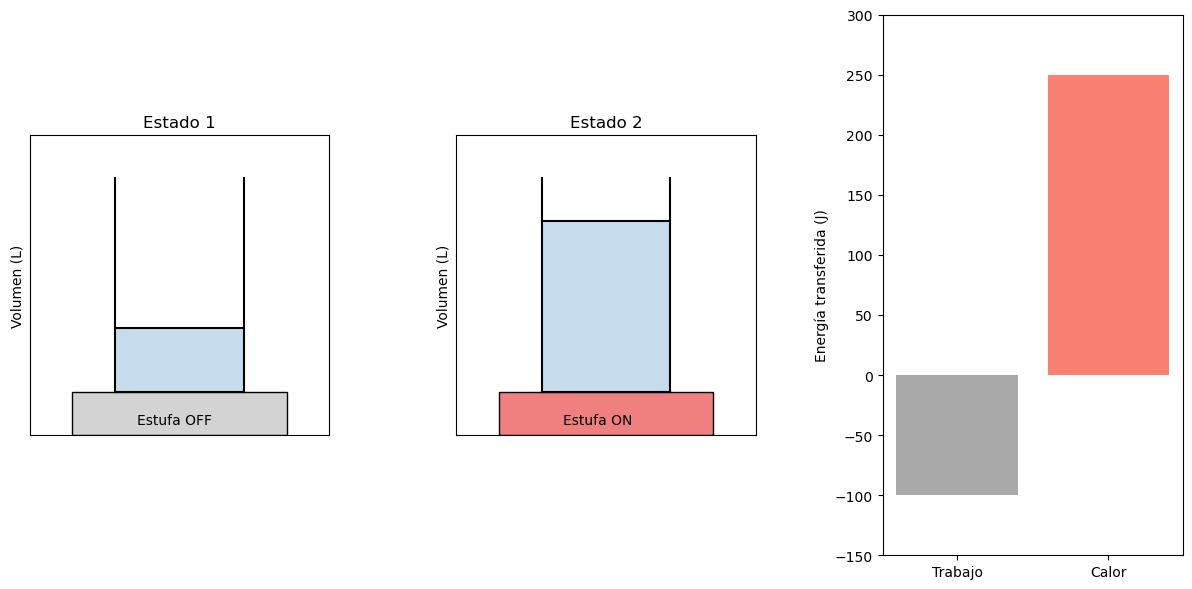

In [25]:
explicar4= """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Según esto ¿a qué se atribuye el cambio de energía interna del agua contenida en el beaker?
</div>
"""
html_explicar4= widgets.HTML(value=explicar4)

out_pregunta = widgets.Output()

def pregunta(alt):
    out_pregunta.clear_output()
    with out_pregunta:
        if alt=='Calor y trabajo':
            print('Respuesta correcta, la energía se está transfiriendo en forma de trabajo mecánico y calor',)
        if alt== 'Trabajo':
            print('Respuesta incorrecta, además de trabajo mecánico el sistema recibe energía en forma de calor')
        if alt== 'Calor':
            print('Respuesta incorrecta, además de calor el sistema intercambia energía en forma de trabajo mecánico')
        else:
            print(' ')

respuestas = ['Calor', 'Trabajo', 'Calor y trabajo']

selec = widgets.RadioButtons(
    options=respuestas,
    value=None,         
    description='Intercambio de energía en forma de:',
    disabled=False
)

def sele_anw(change):
    pregunta(change['new'])

selec.observe(sele_anw, names='value')

explicar5= """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Entonces el cambio de energía del sistema se puede expresar como:  
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
ΔE=ΔU=Q+W
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
ΔU=Q+W
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
O en forma infinitesimal como:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dU=dQ+dW
</div>
"""
html_explicar5= widgets.HTML(value=explicar5)

def grafica_proceso():
    fig, (ax1, ax2,ax3) = plt.subplots(1,3)
    fig.tight_layout()
    m= np.array([4,6,7,10])
    n= np.array([2,2,2,2])
    ax1.plot(m,n,color='black')
    f= np.array([4,6,7,10])
    g= np.array([5,5,5,5])
    ax1.plot(f,g,color='black')
    ax1.fill_between(m,g,n, alpha=0.25)
    l= np.array([4,4,4])
    k= np.array([2,5,12])
    ax1.plot(l, k, color='black')
    u= np.array([10,10,10])
    t= np.array([2,5,12])
    ax1.plot(u, t, color='black')
    ax1.set_ylabel("Volumen (L)")
    rect = Rectangle((2,0),10,2,color='lightgrey',ec='black')
    ax1.add_patch(rect)
    ax1.annotate('Estufa OFF',xy=(5,0.5))
    ax1.set_aspect(1)
    ax1.set_xlim(0, 14)
    ax1.set_ylim(0, 14)
    ax1.set_xticks([])
    ax1.set_yticks([])
    ax1.set_title("Estado 1")
    x= np.array([4,6,7,10])
    y= np.array([2,2,2,2])
    ax2.plot(x,y,color='black')
    e= np.array([4,6,7,10])
    i= np.array([10,10,10,10])
    ax2.plot(e,i,color='black')
    ax2.fill_between(x,i,y, alpha=0.25)
    a= np.array([4,4,4])
    b= np.array([2,5,12])
    ax2.plot(a, b, color='black')
    z= np.array([10,10,10])
    w= np.array([2,5,12])
    ax2.plot(z, w, color='black')
    ax2.set_ylabel("Volumen (L)")
    rect = Rectangle((2,0),10,2,color='lightcoral',ec='black')
    ax2.add_patch(rect)
    ax2.annotate('Estufa ON',xy=(5,0.5))
    ax2.set_aspect(1)
    ax2.set_xlim(0, 14)
    ax2.set_ylim(0, 14)
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_title("Estado 2")
    trabajo1=-100
    calor=250
    energia = "Trabajo"
    energia2 = "Calor"
    ax3.bar(energia, trabajo1, width=0.8, color="darkgray")
    ax3.bar(energia2, calor, width=0.8, color="salmon")
    ax3.set_ylim(ymax=300, ymin=-150)
    ax3.set_ylabel("Energía transferida (J)")
    plt.subplots_adjust(right=2)

comparacion_pro = widgets.Output()

with comparacion_pro:
     grafica_proceso()

display(
    widgets.VBox([html_explicar4,selec,out_pregunta,html_explicar5,comparacion_pro]))


In [26]:
escenario1= """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
En este escenario en particular ¿cuál de las siguientes afirmaciones es verdadera respecto al intercambio de energía en forma de calor entre la estufa, el sistema y los alrededores?  
</div>
"""
html_escenario1= widgets.HTML(value=escenario1)

out_escenario1 = widgets.Output()

def escenario1_texto(formas):
    out_escenario1.clear_output()
    with out_escenario1:
        if formas=='El sistema recibe energía en forma de calor':
            print('Correcto, el sistema recibe energía en forma de calor de la estufa')
        if formas== 'El sistema libera energía en forma de calor':
            print('Incorrecto, el sistema recibe energía en forma de calor de la estufa')
        else:
            print(' ')

anw = ['El sistema recibe energía en forma de calor', 'El sistema libera energía en forma de calor']
dot = widgets.RadioButtons(
    options=anw,
    value=None,         
    disabled=False
)

def on_dot(change):
    escenario1_texto(change['new'])

dot.observe(on_dot, names='value')

display(widgets.VBox([html_escenario1, dot, out_escenario1]))

In [27]:
escenario2= """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
En este escenario en particular ¿cuál de las siguientes afirmaciones es verdadera respecto al intercambio de energía en forma de trabajo mecánico entre la estufa, el sistema y los alrededores?  
</div>
"""
html_escenario2=widgets.HTML(value=escenario2)

out_escenario2 = widgets.Output()

def escenario_2texto(re):
    out_escenario2.clear_output()
    with out_escenario2:
        if re=='El sistema recibe trabajo mecánico':
            print('Incorrecto, el sistema transfiere energía en forma de trabajo mecánico a los alrededores')
        if re== 'El sistema transfiere trabajo mecánico':
            print('Correcto, el sistema transfiere energía en forma de trabajo mecánico a los alrededores cuando la sustancia se expande')
        else:
            print(' ')

ser= ['El sistema recibe trabajo mecánico','El sistema transfiere trabajo mecánico']
push = widgets.RadioButtons(options=ser, value=None, disabled=False)

def on_push(change):
    escenario_2texto(change['new'])

push.observe(on_push, names='value')

display(widgets.VBox([html_escenario2, push, out_escenario2]))


In [28]:
extrabajo= """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
El trabajo mecánico cuando trabajamos con sistemas cerrados se puede expresar como:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dW= - PdV
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
En el caso del calor no tenemos una definición matemática que podamos utilizar, por lo que tendremos que plantear matemáticamente el balance de energía y estimar el calor con esta expresión matemática.
</div>
"""
html_extrabajo=widgets.HTML(value=extrabajo)
display(html_extrabajo)


HTML(value='\n<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1…

In [29]:
gas= """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Veamos el caso de un gas ideal sometido a un proceso isobárico (es decir que se realiza a presión constante). Durante el proceso a presión constante el volumen de la sustancia cambiará. Y podemos estimar cuanta energía se intercambia durante el proceso utilizando la primera ley de la Termodinámica. Matemáticamente, podemos expresar su balance de energía como:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dU=dQ+dW
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Podríamos empezar evaluando el trabajo mecánico del proceso:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dW= - PdV
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
&int;dW=- &int;PdV
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
La presión es constante, por lo que sale de la integral, y sólo queda integrar el dV que se convierte en el cambio de volumen (volumen final menos volumen incial):
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
W= - PΔV= - P(V<sub>final</sub>-V<sub>inicial</sub>)
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
¿Por qué al integrar el dW obtuvimos W y no ΔW?
"""
html_gas=widgets.HTML(value=gas)

out_re = widgets.Output()

def res_tra(pu):
    out_re.clear_output()
    with out_re:
        if pu=='El trabajo es una función de trayectoria':
            print('Correcto, no hay un cambio de trabajo, sino que energía transferida en forma de trabajo al realizar el proceso')
        if pu== 'El trabajo es una función de estado':
            print('Incorrecto, el trabajo es una función de trayectoria, por lo que se estima la energía transferida en forma de trabajo al realizar el proceso')
        else:
            print(' ')

pa=['El trabajo es una función de trayectoria','El trabajo es una función de estado']
click = widgets.RadioButtons(options=pa, value=None, disabled=False)

def on_click(change):
    res_tra(change['new'])

click.observe(on_click, names='value')

display(widgets.VBox([html_gas, click, out_re]))


In [30]:
calor= """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Ya que tenemos una expresión para estimar la energía transferida en forma de trabajo, estimemos la que se transfiere en forma de calor, usando la expresión matemática del balance de energía:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dU=dQ+dW
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dQ=dU-dW
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Para un gas ideal el diferencial de energía interna se expresa como:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dU=C<sub>v</sub>dT
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Que en este caso al integrarse daría como resultado:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
ΔU=C<sub>v</sub>ΔT=C<sub>v</sub>(T<sub>final</sub>-T<sub>inicial</sub>)
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Entonces para un gas ideal sometido a un proceso isobárico, la energía transferida en forma de calor se estima como:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
Q=ΔU-W=C<sub>v</sub>(T<sub>final</sub>-T<sub>inicial</sub>)-(-P(V<sub>final</sub>-V<sub>inicial</sub>))
</div>
"""
html_calor=widgets.HTML(value=calor)
display(html_calor)

HTML(value='\n<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1…

In [31]:
problema1="""
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
A continuación, puedes evaluar que sucede con un gas ideal que se somete a un proceso isobárico reversible. Puedes escoger el rango de volumen entre 5 y 20 L/mol y una presión entre 70 y 500 kPa. Además, en la gráfica PV se muestra el resaltada el área bajo la curva, que representa el trabajo mecánico del proceso. Observa lo que sucede con las barras que representan la energía transferida en forma de calor y trabajo mecánico. 
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Simula primero un proceso en el que el volumen del gas aumenta. ¿El sistema recibe energía en forma de calor para provocar la expansión o libera energía en forma de calor? ¿Qué sucede con el trabajo mecánico?
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Ahora simula un proceso en el que el volumen del gas disminuye. ¿Qué sucede con la energía en forma de calor en este escenario? ¿Qué sucede con el trabajo mecánico?
</div>
"""
html_problema1=widgets.HTML(value=problema1)
display(html_problema1)


HTML(value='\n<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1…

In [32]:
volmin = widgets.BoundedFloatText(description=' Vm1 (L/mol) =',value=5, min=5, max=20, step=0.1)
volmax = widgets.BoundedFloatText(description=' Vm2 (L/mol) =',value=10, min=5, max=20, step=0.1)
presion = widgets.BoundedFloatText(description=' Presión (kPa) =',value=100, min=70, max=500, step=0.1)

def temperatura (volmin,volmax,presion):
    tmin = volmin*presion/8.314
    tmax = volmax*presion/8.314
    print ("Tmin (K) =", tmin)
    print ("Tmax (K) =", tmax)
    return (tmin, tmax)
    
def f3(volmin,volmax,presion):
    tmin = volmin*presion/8.314
    tmax = volmax*presion/8.314                  
    x = np.linspace(1,60,500)
    ec1=8.314*tmin/x
    plt.plot(x,ec1, color='gray')
    plt.ylim(0, 600)
    plt.xlim(0, 30)
    plt.xlabel('Volumen (L/mol)')
    ec2=8.314*tmax/x
    plt.plot(x,ec2, color='gray')
    ec3=presion+x-x
    plt.plot(x,ec3, color='blue')
    graf1 = plt.fill_between(x,ec3, where =[(x>volmin) and (x<volmax) for x in x],color='gray', alpha=0.2)
    graf2 = plt.fill_between(x,ec3, where =[(x>volmax) and (x<volmin) for x in x], color='gray', alpha=0.2)
    plt.ylabel('Presión (kPa)')
    if volmin<volmax:
        display(graf1)
    else:
        display(graf2)    
         
def cilindro(volmin,volmax,presion):
    fig, (ax1, ax2,ax3) = plt.subplots(1,3)
    fig.tight_layout()
    x= np.array([5,6,7,8])
    y= np.array([volmin,volmin,volmin,volmin])
    a= np.array([5,5,5])
    b= np.array([0,8,30])
    z= np.array([8,8,8])
    w= np.array([0,8,30])
    ax1.plot(x, y, color='black')
    ax1.fill_between(x, y, alpha=0.25)
    ax1.plot(a, b, color='black')
    ax1.plot(z, w, color='black')
    ax1.set_title('Estado inicial')
    ax1.set_xticks([])
    m= np.array([5,6,7,8])
    n= np.array([volmax,volmax,volmax,volmax])
    r= np.array([5,5,5])
    s= np.array([0,8,30])
    e= np.array([8,8,8])
    i= np.array([0,8,30])
    ax2.plot(m,n, color='black')
    ax2.fill_between(m,n, alpha =0.25)
    ax2.plot(r,s,color='black')
    ax2.plot(e,i,color='black')
    ax2.set_ylabel('Volumen molar (L/mol)')
    ax1.set_ylabel('Volumen molar (L/mol)')
    ax2.set_title('Estado final')
    ax1.set_xlim(xmax=10, xmin=3)
    ax2.set_xlim(xmax=10, xmin=3)
    ax1.set_ylim(ymax=30, ymin=0)
    ax2.set_ylim(ymax=30, ymin=0)
    ax2.set_xticks([])
    plt.subplots_adjust(right=3)
    trabajo2 = -presion*(volmax-volmin)
    calor2  = 20.7684*((volmax*presion/8.314)-(volmin*presion/8.314))-trabajo2
    energiaa = "Trabajo"
    energiab = "Calor"
    ax3.bar(energiaa, trabajo2, width=0.8, color="darkgray")
    ax3.bar(energiab, calor2, width=0.8, color="salmon")
    ax3.set_ylim(ymax=10000, ymin=-10000)
    ax3.set_ylabel('Energía transferida (J/mol)')
    print ("Trabajo (J/mol) =", trabajo2)
    print ("Calor (J/mol) =", calor2)
    return(trabajo2, calor2)
    return(ax1,ax2,ax3)
    
out1 = widgets.interactive_output(temperatura, {'volmin': volmin,'volmax': volmax,'presion': presion})
out3 = widgets.interactive_output(f3, {'volmin': volmin,'volmax': volmax, 'presion': presion})
out4 = widgets.interactive_output(cilindro, {'volmin': volmin, 'volmax': volmax, 'presion': presion})


display(volmin)
display(volmax)
display(presion)
display(out1)
display(out4)
display(out3)


BoundedFloatText(value=5.0, description=' Vm1 (L/mol) =', max=20.0, min=5.0, step=0.1)

BoundedFloatText(value=10.0, description=' Vm2 (L/mol) =', max=20.0, min=5.0, step=0.1)

BoundedFloatText(value=100.0, description=' Presión (kPa) =', max=500.0, min=70.0, step=0.1)

Output()

Output()

Output()

In [33]:
pregunta2="""
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Para que el gas se expanda en el proceso isobárico ¿qué necesita el sistema?
</div>
"""
html_pregunta2=widgets.HTML(value=pregunta2)

out_pregunta2 = widgets.Output()

def texto_pregunta(tus):
    out_pregunta2.clear_output()
    with out_pregunta2:
        if tus=='Transferir calor hacia los alrededores':
            print('Incorrecto, el sistema debe recibir energía en forma de calor de los alrededores, por ejemplo una estufa u otra fuente de energía')
        if tus== 'Recibir calor de los alredores':
            print('Correcto, el sistema recibe energía en forma de calor de los alredores, por ejemplo una estufa u otra fuente de energía')
        else:
            print(' ')

bar = ['Transferir calor hacia los alrededores', 'Recibir calor de los alredores']

isobar = widgets.RadioButtons(
    options=bar,
    value=None,         
    disabled=False
)

def on_isobar(change):
    texto_pregunta(change['new'])

isobar.observe(on_isobar, names='value')

display(
    widgets.VBox([html_pregunta2,isobar,out_pregunta2]))

In [34]:
pregunta3="""
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Cuando el gas recibe energía en forma de calor ¿qué le sucede a la energía interna del sistema?
</div>
"""
html_pregunta3=widgets.HTML(value=pregunta3)

out_pregunta3 = widgets.Output()

def texto_pregunta3(ops):
    out_pregunta3.clear_output()
    with out_pregunta3:
        if ops=='Aumenta':
            print('Correcto, la energía interna de las partículas del sistema aumenta, haciendo que estas se mueven más rápido')
        if ops== 'Disminuye':
            print('Incorrecto, la energía en forma de calor hace que la energía interna de las partículas aumente, haciendo que las partículas se muevan más rápido')
        else:
            print(' ')

atm = ['Aumenta', 'Disminuye']

pcte = widgets.RadioButtons(
    options=atm,
    value=None,         
    disabled=False
)

def on_atm(change):
    texto_pregunta3(change['new'])

pcte.observe(on_atm, names='value')

display(
    widgets.VBox([html_pregunta3,pcte,out_pregunta3]))


In [35]:
pregunta4="""
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Cuando el gana energía en forma de calor ¿qué sucede con la transferencia de energía en forma de trabajo mecánico?
</div>
"""
html_pregunta4=widgets.HTML(value=pregunta4)

out_pregunta4 = widgets.Output()

def texto_pregunta4(ci):
    out_pregunta4.clear_output()
    with out_pregunta4:
        if ci=='Se transfiere trabajo mecánico':
            print('Correcto, la sustancia aumenta su volumen impulsando las partículas hacia arriba en este sistema')
        if ci== 'Se absorve trabajo mecánico':
            print('Incorrecto, la sustancia aumenta su volumen impulsando las partículas hacia arriba en este sistema')
        else:
            print(' ')

hg = ['Se transfiere trabajo mecánico', 'Se absorve trabajo mecánico']

trac = widgets.RadioButtons(
    options=hg,
    value=None,         
    disabled=False
)

def on_hg(change):
    texto_pregunta4(change['new'])

trac.observe(on_hg, names='value')

display(
    widgets.VBox([html_pregunta4,trac,out_pregunta4]))

In [36]:
pregunta5="""
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
En el escenario en el que el volumen del gas disminuye, ¿en qué dirección se debe transferir la energía en forma de calor?
</div>
"""
html_pregunta5=widgets.HTML(value=pregunta5)

out_pregunta5 = widgets.Output()

def texto_pregunta5(ti):
    out_pregunta5.clear_output()
    with out_pregunta5:
        if ti=='Del sistema a los alrededores':
            print('Correcto, el sistema debe perder energía en forma de calor')
        if ti== 'De los alrededores al sistema':
            print('Incorrecto, el sistema debe perder energía en forma de calor')
        else:
            print(' ')

psi = ['Del sistema a los alrededores', 'De los alrededores al sistema']

sion = widgets.RadioButtons(
    options=psi,
    value=None,         
    disabled=False
)

def on_sion(change):
    texto_pregunta5(change['new'])

sion.observe(on_sion, names='value')

display(
    widgets.VBox([html_pregunta5,sion,out_pregunta5]))

In [37]:
isoterexplicar = """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Ahora veamos el caso de un gas ideal sometido a un proceso isotérmico. Podemos empezar expresando el balance de energía matemáticamente como:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dU=dQ+dW
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
El diferencial de energía interna de un gas ideal es:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dU=C<sub>v</sub>dT
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Si la expresión se integra se obtiene:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
ΔU = C<sub>v</sub> ΔT = C<sub>v</sub> (T<sub>final</sub> - T<sub>inicial</sub>)
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Dado que se trata de un proceso isotérmico (a temperatura constante) el cambio de temperatura es igual a cero:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
ΔU = 0
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dU = 0
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Con esto el balance de energía se modifica de esta manera:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dU=dQ+dW
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
<del>dU</del> = dQ+dW
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dQ = - dW
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Esto quiere decir que si un gas ideal se somete a un proceso isotérmico la cantidad de energía intercambiada con los alrededores en forma de calor es igual al negativo de la energía intercambiada en forma de trabajo mecánico. Es decir que el calor y el trabajo en este caso tienen el mismo valor pero diferente signo.
</div>
"""
html_isoterexplicar= widgets.HTML(value=isoterexplicar)
display(html_isoterexplicar)

HTML(value='\n<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1…

In [38]:
isoterexplicar2 = """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Lo anterior implica que si estimamos el trabajo mecánico también estaremos estimando la energía intercambiada como calor. Al tratarse de un sistema cerrado la ecuación para estimar el trabajo mecánico es:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
dW= - PdV
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
La variable de integración en la expresión del lado derecho de la ecuación es el volumen, pero la presión también aparece en la ecuación, y en el proceso isotérmico la presión no permance constate. Entonces, para poder resolver la integral, la presión se reemplaza por una expresión matemática que exprese la relación entre volumen y presión, la ecuación de estado, en este caso gas ideal.
</div>
<div style="background-color: gainsboro; padding: 20px; font-family: Times New Roman; font-size:1.3em; color:black; text-align:center;">
dW = -
<div style="display: inline-block; text-align: center; vertical-align: middle;">
  <span style="display: block; border-bottom: 1px solid black; padding: 0 5px;">RT</span>
  <span style="display: block; padding: 0 5px;">V</span>
</div>
dV
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Al integrar se toman como límites de integración el volumen inicial y el volumen final: 
</div>
<div style="background-color: gainsboro; padding: 20px; font-family: Times New Roman; font-size:1.3em; color:black; text-align:center;">
<span style="font-size: 1.8em; vertical-align: middle; padding-right: 5px;">&int;</span>
dW = 
<div style="display: inline-block; text-align: center; vertical-align: middle;">
<span style="font-size: 1.8em; vertical-align: middle; padding-right: 5px;">&int;</span>
</div>
<div style="display: inline-block; text-align: center; vertical-align: middle;">
  <span style="display: block; border-bottom: 1px solid black; padding: 0 5px;"> - RT</span>
  <span style="display: block; padding: 0 5px;">V</span>
</div>
dV
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Resolviendo la integral obtenemos:
</div>
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;text-align:center;">
W = - RT
<span style="font-size: 2em; vertical-align: middle; padding-right: 5px;font-weight: normal;">(</span>
<div style="display: inline-block; text-align: center; vertical-align: middle;">
  <span style="display: block; border-bottom: 1px solid black; padding: 0 5px;">1</span>
  <span style="display: block; padding: 0 5px;">V<sub>final</sub></span>
</div>
-
<div style="display: inline-block; text-align: center; vertical-align: middle;">
  <span style="display: block; border-bottom: 1px solid black; padding: 0 5px;">1</span>
  <span style="display: block; padding: 0 5px;">V<sub>inicial</sub></span>
</div>
<span style="font-size: 2em; vertical-align: middle; padding-right: 5px;font-weight: normal;">)</span>
"""
html_isoterexplicar2= widgets.HTML(value=isoterexplicar2)
display(html_isoterexplicar2)

HTML(value='\n<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1…

In [39]:
ahora = """
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Ahora puedes utilizar las siguientes ilustraciones para evaluar que sucede con un gas ideal sometido a un proceso isotérmico reversible. En este caso puedes elegir el volumen inicial y el volumen final, ambos en un rango de 2 a 20 L/mol. Evalúa dos posibilidades: primero que el volumen del gas aumente, y luego que el volumen del gas disminuya.
</div>
"""
html_ahora= widgets.HTML(value=ahora)
display(html_ahora)

HTML(value='\n<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1…

In [40]:
volmin = widgets.BoundedFloatText(description=' Vm1 (L/mol) =',value=5, min=2, max=20, step=0.1)
volmax = widgets.BoundedFloatText(description=' Vm2 (L/mol) =',value=10, min=2, max=20, step=0.1)
 
def f4(volmin,volmax):
    x = np.linspace(1,20,500)
    ec=8.314*298.15/x
    plt.plot(x,ec)
    plt.ylim(0, 1000)
    graf1 = plt.fill_between(x,ec, where =[(x>volmin) and (x<volmax) for x in x],color='gray', alpha=0.2)
    graf2 = plt.fill_between(x,ec, where =[(x>volmax) and (x<volmin) for x in x],color='gray', alpha=0.2)
    plt.xlabel('Volumen (L/mol)')
    plt.ylabel('Presión (kPa)')
    if volmin<volmax:
        display(graf1)
    else:
        display(graf2)  
         
def cilindro2(volmin,volmax):
    fig, (ax1, ax2,ax3) = plt.subplots(1,3)
    fig.tight_layout()
    x= np.array([5,6,7,8])
    y= np.array([volmin,volmin,volmin,volmin])
    a= np.array([5,5,5])
    b= np.array([0,8,30])
    z= np.array([8,8,8])
    w= np.array([0,8,30])
    ax1.plot(x, y, color='black')
    ax1.fill_between(x, y, alpha=0.25)
    ax1.plot(a, b, color='black')
    ax1.plot(z, w, color='black')
    ax1.set_title('Estado inicial')
    ax1.set_xticks([])
    m= np.array([5,6,7,8])
    n= np.array([volmax,volmax,volmax,volmax])
    r= np.array([5,5,5])
    s= np.array([0,8,30])
    e= np.array([8,8,8])
    i= np.array([0,8,30])
    ax2.plot(m,n, color='black')
    ax2.fill_between(m,n, alpha =0.25)
    ax2.plot(r,s,color='black')
    ax2.plot(e,i,color='black')
    ax2.set_ylabel('Volumen molar (L/mol)')
    ax1.set_ylabel('Volumen molar (L/mol)')
    ax2.set_title('Estado final')
    ax1.set_xlim(xmax=10, xmin=3)
    ax2.set_xlim(xmax=10, xmin=3)
    ax2.set_xticks([])
    plt.subplots_adjust(right=3)
    pres1=8.314*298.15/volmin
    pres2=8.314*298.15/volmax
    trabajoinf=2478.8191*sp.log(volmin).evalf()
    trabajosup=2478.8191*sp.log(volmax).evalf()
    trabajo3 = -(trabajosup-trabajoinf).evalf()
    calor3 = -trabajo3
    energia3 = "Trabajo"
    energi3a = "Calor"
    ax3.bar(energia3, trabajo3, width=0.8, color="darkgray")
    ax3.bar(energi3a, calor3, width=0.8, color="salmon")
    ax3.set_ylim(ymax=10000, ymin=-10000)
    ax3.set_ylabel('Energía transferida (J/mol)')
    print ("Presión 1 (kPa) =", pres1)
    print ("Presión 2 (kPa) =", pres2)
    print ("Trabajo (J/mol) =", trabajo3)
    print ("Calor (J/mol) =", calor3)
    return(trabajo3, calor3)
    return(ax1,ax2,ax3)
    
out5 = widgets.interactive_output(f4, {'volmin': volmin,'volmax': volmax})
out6 = widgets.interactive_output(cilindro2, {'volmin': volmin, 'volmax': volmax})


display(volmin)
display(volmax)
display(out6)
display(out5)

BoundedFloatText(value=5.0, description=' Vm1 (L/mol) =', max=20.0, min=2.0, step=0.1)

BoundedFloatText(value=10.0, description=' Vm2 (L/mol) =', max=20.0, min=2.0, step=0.1)

Output()

Output()

In [41]:
pregunta6="""
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
En el escenario en el que el volumen del gas aumenta de forma isotérmica ¿el sistema requiere intercambiar energía en forma de calor con los alrededores?
</div>
"""
html_pregunta6=widgets.HTML(value=pregunta6)

out_pregunta6 = widgets.Output()

def texto_pregunta6(altr):
    out_pregunta6.clear_output()
    with out_pregunta6:
        if altr=='Si':
            print('Correcto, el sistema necesita recibir energía en forma de calor. ¿Por qué?')
        if altr== 'No':
            print('Incorrecto, el sistema si necesita recibir energía en forma de calor. ¿Por qué?')
        else:
            print(' ')

nion = ['Si', 'No']

calor = widgets.RadioButtons(
    options=nion,
    value=None,         
    disabled=False
)

def on_nion(change):
    texto_pregunta6(change['new'])

calor.observe(on_nion, names='value')

display(
    widgets.VBox([html_pregunta6,calor,out_pregunta6]))


In [42]:
pregunta7="""
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
En el proceso isotérmico, cuando el volumen del gas aumenta ¿cuál es la dirección de inetercambio de energía en forma de calor entre el sistema y los alrededores?
</div>
"""
html_pregunta7=widgets.HTML(value=pregunta7)

out_pregunta7 = widgets.Output()

def texto_pregunta7(gat):
    out_pregunta7.clear_output()
    with out_pregunta7:
        if gat=='Del sistema hacia los alrededores':
            print('Correcto, el sistema transfiere energía en forma de trabajo hacia los alrededores')
        if gat== 'De los alrededores hacia el sistema':
            print('Incorrecto, el sistema transfiere energía en forma de trabajo hacia los alrededores')
        else:
            print(' ')

nino = ['Del sistema hacia los alrededores',  'De los alrededores hacia el sistema']

ton = widgets.RadioButtons(
    options=nino,
    value=None,         
    disabled=False
)

def on_nino(change):
    texto_pregunta7(change['new'])

ton.observe(on_nino, names='value')

display(
    widgets.VBox([html_pregunta7,ton,out_pregunta7]))

In [43]:
pregunta8="""
<div style="background-color: gainsboro; padding: 20px;font-family: Times New Roman; font-size:1.3em; color:black;">
Si el proceso es isotérmico y se quiere reducir el volumen del gas, ¿cuál es la dirrección de intercambio de energía en forma de calor entre el sistema y los alrededores?
</div>
"""
html_pregunta8=widgets.HTML(value=pregunta8)

out_pregunta8 = widgets.Output()

def texto_pregunta8(blue):
    out_pregunta8.clear_output()
    with out_pregunta8:
        if blue=='Del sistema hacia los alrededores':
            print('Incorrecto, el sistema debe perder energía en forma de calor y liberarla hacia los alrededores, de lo contrario el volumen del gas aumentaría')
        if blue== 'De los alrededores hacia el sistema':
            print('Correcto, el sistema debe perder energía en forma de calor y liberarla hacia los alredores')
        else:
            print(' ')

tio = ['Del sistema hacia los alrededores',  'De los alrededores hacia el sistema']

tone = widgets.RadioButtons(
    options=tio,
    value=None,         
    disabled=False
)

def on_tone(change):
    texto_pregunta8(change['new'])

tone.observe(on_tone, names='value')

display(
    widgets.VBox([html_pregunta8,tone,out_pregunta8]))

In [44]:
%reload_ext watermark
%watermark -v -m -p matplotlib,numpy,sympy,ipywidgets,voila,IPython.display



Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.7.0

matplotlib     : 3.10.6
numpy          : 2.3.5
sympy          : 1.14.0
ipywidgets     : 8.1.7
voila          : 0.5.11
IPython.display: unknown

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 11
Machine     : AMD64
Processor   : Intel64 Family 6 Model 181 Stepping 0, GenuineIntel
CPU cores   : 14
Architecture: 64bit

